In [1]:
import sys
import pathlib
import numpy as np
import pandas as pd
import plotnine as p9
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import warnings

warnings.filterwarnings("ignore")
sys.path.insert(0, "../utils/")
from data_loader import load_data, load_train_test_data

In [2]:
# data path
data_directory = "data/"

In [3]:
# load the training data
train_data = load_train_test_data(
    data_directory, train_or_test="train", load_gene_stats=False, drop_columns=False
)

In [4]:
# set a unique dataframe that can be appended from
training_df_age = train_data

# group by age and create new dataframes that can be appended to
groups = training_df_age.groupby("age_and_sex")
adult_effect_df = pd.DataFrame()
ped_effect_df = pd.DataFrame()
for name, training_df_age in groups:

    # append rows that contain Adult samples (male or female) to the new adult effect dataframe
    if name == "Adult_Male" or name == "Adult_Female" or name == "Adult_nan":
        adult_effect_df = pd.concat([adult_effect_df, training_df_age])
        adult_effect_df = adult_effect_df.reset_index(drop=True)

    # append rows that contain Pediatric samples (male ore female) to the new pediatric dataframe
    else:
        ped_effect_df = pd.concat([ped_effect_df, training_df_age])
        ped_effect_df = ped_effect_df.reset_index(drop=True)

In [5]:
# set a unique dataframe that can be appended from
training_df_sex = train_data

# group by sex and create new dataframes to be appended to
groups_sex = training_df_sex.groupby("age_and_sex")
male_effect_df = pd.DataFrame()
female_effect_df = pd.DataFrame()
for name, training_df_sex in groups_sex:

    # append rows that contain Male samples (Adult or Pediatric) to the new male effect dataframe and filter out samples that contain no gender info
    if (
        name == "Adult_Male"
        or name == "Pediatric_Male"
        and name != "Pediatric_nan"
        and name != "Adult_nan"
    ):
        male_effect_df = pd.concat([male_effect_df, training_df_sex])
        male_effect_df = male_effect_df.reset_index(drop=True)

    # append rows that contain Female samples (Adult or Pediatric) to the new female effect dataframe and filter out samples that contain no gender info
    elif (
        name == "Adult_Female"
        or name == "Pediatric_Female"
        and name != "Pediatric_nan"
        and name != "Adult_nan"
    ):
        female_effect_df = pd.concat([female_effect_df, training_df_sex])
        female_effect_df = female_effect_df.reset_index(drop=True)

In [6]:
print(adult_effect_df.shape)
adult_effect_df.head(3)

(569, 17109)


,ModelID,A1BG (1),A1CF (29974),A2M (2),A2ML1 (144568),A3GALT2 (127550),A4GALT (53947),A4GNT (51146),AAAS (8086),AACS (65985),...,ZWINT (11130),ZXDA (7789),ZXDB (158586),ZXDC (79364),ZYG11A (440590),ZYG11B (79699),ZYX (7791),ZZEF1 (23140),ZZZ3 (26009),age_and_sex
0,ACH-002511,-0.058905,-0.018946,0.067556,0.159318,-0.170766,0.021027,-0.001709,0.022658,-0.070779,...,-0.128634,-0.038578,0.017898,-0.101944,-0.111962,-0.143088,-0.105750,-0.119073,-0.203293,Adult_Female
1,ACH-001328,-0.085910,-0.044116,0.025245,-0.127086,-0.003605,-0.113595,0.043094,0.011756,-0.029211,...,-0.528823,0.067074,0.026188,-0.112285,0.007935,-0.037567,0.157758,-0.230996,-0.205591,Adult_Female
2,ACH-000581,-0.130765,-0.380984,0.080065,0.144750,-0.237834,-0.019885,0.186176,0.130135,0.145889,...,-0.223806,0.088617,-0.052296,0.056289,0.005258,0.060675,-0.098955,-0.290145,-0.240998,Adult_Female


In [7]:
print(ped_effect_df.shape)
ped_effect_df.head(3)

(101, 17109)


,ModelID,A1BG (1),A1CF (29974),A2M (2),A2ML1 (144568),A3GALT2 (127550),A4GALT (53947),A4GNT (51146),AAAS (8086),AACS (65985),...,ZWINT (11130),ZXDA (7789),ZXDB (158586),ZXDC (79364),ZYG11A (440590),ZYG11B (79699),ZYX (7791),ZZEF1 (23140),ZZZ3 (26009),age_and_sex
0,ACH-001618,-0.060817,-0.280227,-0.029631,-0.117757,-0.066095,0.033039,0.367531,0.191806,-0.119773,...,-0.079149,-0.112526,-0.063046,-0.076179,0.096559,-0.406814,-0.168632,-0.261766,0.003597,Adult_Unknown
1,ACH-001028,-0.058434,-0.124365,-0.004526,0.044687,-0.119767,-0.135910,-0.029757,0.100100,-0.038721,...,-0.484204,-0.073651,-0.080406,-0.123952,-0.087251,-0.120401,0.048192,-0.238780,-0.455066,Pediatric_Female
2,ACH-001212,-0.165505,-0.107355,0.264424,0.200538,-0.129385,-0.015351,0.128600,-0.293800,-0.063891,...,-0.239258,-0.007196,-0.034968,0.102970,-0.034861,-0.268647,-0.060592,-0.622535,-0.368041,Pediatric_Female


In [8]:
print(male_effect_df.shape)
male_effect_df.head(3)

(378, 17109)


,ModelID,A1BG (1),A1CF (29974),A2M (2),A2ML1 (144568),A3GALT2 (127550),A4GALT (53947),A4GNT (51146),AAAS (8086),AACS (65985),...,ZWINT (11130),ZXDA (7789),ZXDB (158586),ZXDC (79364),ZYG11A (440590),ZYG11B (79699),ZYX (7791),ZZEF1 (23140),ZZZ3 (26009),age_and_sex
0,ACH-000213,-0.137704,-0.209328,0.035861,0.095985,-0.103421,-0.038196,-0.113301,-0.082544,-0.172621,...,-0.518846,0.089815,0.182594,0.013440,0.284268,-0.325811,0.028021,-0.013548,-0.571625,Adult_Male
1,ACH-001353,-0.014122,-0.064918,-0.066487,-0.068518,-0.199239,-0.100704,0.101312,-0.096683,0.114865,...,-0.628890,0.178172,0.011137,-0.107975,-0.120189,-0.147368,-0.000751,-0.159604,-0.458500,Adult_Male
2,ACH-000271,-0.371638,0.084831,-0.043180,0.021181,-0.206486,-0.099801,0.137065,-0.333629,-0.162360,...,0.309595,0.142709,-0.032421,-0.002199,-0.057900,0.063855,0.026486,-0.038851,0.054204,Adult_Male


In [9]:
print(female_effect_df.shape)
female_effect_df.head(3)

(285, 17109)


,ModelID,A1BG (1),A1CF (29974),A2M (2),A2ML1 (144568),A3GALT2 (127550),A4GALT (53947),A4GNT (51146),AAAS (8086),AACS (65985),...,ZWINT (11130),ZXDA (7789),ZXDB (158586),ZXDC (79364),ZYG11A (440590),ZYG11B (79699),ZYX (7791),ZZEF1 (23140),ZZZ3 (26009),age_and_sex
0,ACH-002511,-0.058905,-0.018946,0.067556,0.159318,-0.170766,0.021027,-0.001709,0.022658,-0.070779,...,-0.128634,-0.038578,0.017898,-0.101944,-0.111962,-0.143088,-0.105750,-0.119073,-0.203293,Adult_Female
1,ACH-001328,-0.085910,-0.044116,0.025245,-0.127086,-0.003605,-0.113595,0.043094,0.011756,-0.029211,...,-0.528823,0.067074,0.026188,-0.112285,0.007935,-0.037567,0.157758,-0.230996,-0.205591,Adult_Female
2,ACH-000581,-0.130765,-0.380984,0.080065,0.144750,-0.237834,-0.019885,0.186176,0.130135,0.145889,...,-0.223806,0.088617,-0.052296,0.056289,0.005258,0.060675,-0.098955,-0.290145,-0.240998,Adult_Female


In [10]:
# drop the string values from all dataframes
adult_effect_df_float = adult_effect_df.drop(
    columns=["ModelID", "age_and_sex"]
)
ped_effect_df_float = ped_effect_df.drop(columns=["ModelID", "age_and_sex"])

male_effect_df_float = male_effect_df.drop(columns=["ModelID", "age_and_sex"])
female_effect_df_float = female_effect_df.drop(
    columns=["ModelID", "age_and_sex"]
)

effect_df = train_data.drop(columns="age_and_sex")
effect_df = effect_df.set_index("ModelID")

In [11]:
# t_test comparing gene dependencies in adult vs pediatric samples
t_test = ttest_ind(adult_effect_df_float, ped_effect_df_float)
t_test = pd.DataFrame(t_test).T
t_test.columns = ["t_stat", "p_value"]
print(t_test.shape)
t_test.head(3)

(17107, 2)

,t_stat,p_value
0,1.867918,0.062211
1,-0.984714,0.325121
2,0.902875,0.366917


In [12]:
# t_test comparing gene dependencies in male vs female samples
t_test_sex = ttest_ind(male_effect_df_float, female_effect_df_float)
t_test_sex = pd.DataFrame(t_test_sex).T
t_test_sex.columns = ["t_stat", "p_value"]
print(t_test_sex.shape)
t_test_sex.head(3)

(17107, 2)


,t_stat,p_value
0,-0.636459,0.524698
1,0.690565,0.490082
2,1.550377,0.121530


In [13]:
print(effect_df.shape)
effect_df.head(3)

(670, 17107)


,A1BG (1),A1CF (29974),A2M (2),A2ML1 (144568),A3GALT2 (127550),A4GALT (53947),A4GNT (51146),AAAS (8086),AACS (65985),AADAC (13),...,ZWILCH (55055),ZWINT (11130),ZXDA (7789),ZXDB (158586),ZXDC (79364),ZYG11A (440590),ZYG11B (79699),ZYX (7791),ZZEF1 (23140),ZZZ3 (26009)
ModelID,,,,,,,,,,,,,,,,,,,,,
ACH-000213,-0.137704,-0.209328,0.035861,0.095985,-0.103421,-0.038196,-0.113301,-0.082544,-0.172621,-0.000008,...,-0.166084,-0.518846,0.089815,0.182594,0.013440,0.284268,-0.325811,0.028021,-0.013548,-0.571625
ACH-002511,-0.058905,-0.018946,0.067556,0.159318,-0.170766,0.021027,-0.001709,0.022658,-0.070779,0.120043,...,-0.106828,-0.128634,-0.038578,0.017898,-0.101944,-0.111962,-0.143088,-0.105750,-0.119073,-0.203293
ACH-001328,-0.085910,-0.044116,0.025245,-0.127086,-0.003605,-0.113595,0.043094,0.011756,-0.029211,0.184545,...,-0.225414,-0.528823,0.067074,0.026188,-0.112285,0.007935,-0.037567,0.157758,-0.230996,-0.205591


In [14]:
# calculate variance of each gene then send the results plus the gene info into a new dataframe
variance = effect_df.var()
variance_list = variance.tolist()
column_names = ["variance"]
variance_df = pd.DataFrame(variance, columns=column_names)
variance_df = variance_df.sort_index(ascending=True).reset_index()
variance_df = variance_df.rename(columns={"index": "gene_ID"})
print(variance_df.shape)
variance_df.head(3)

(17107, 2)


,gene_ID,variance
0,A1BG (1),0.010377
1,A1CF (29974),0.012438
2,A2M (2),0.008775


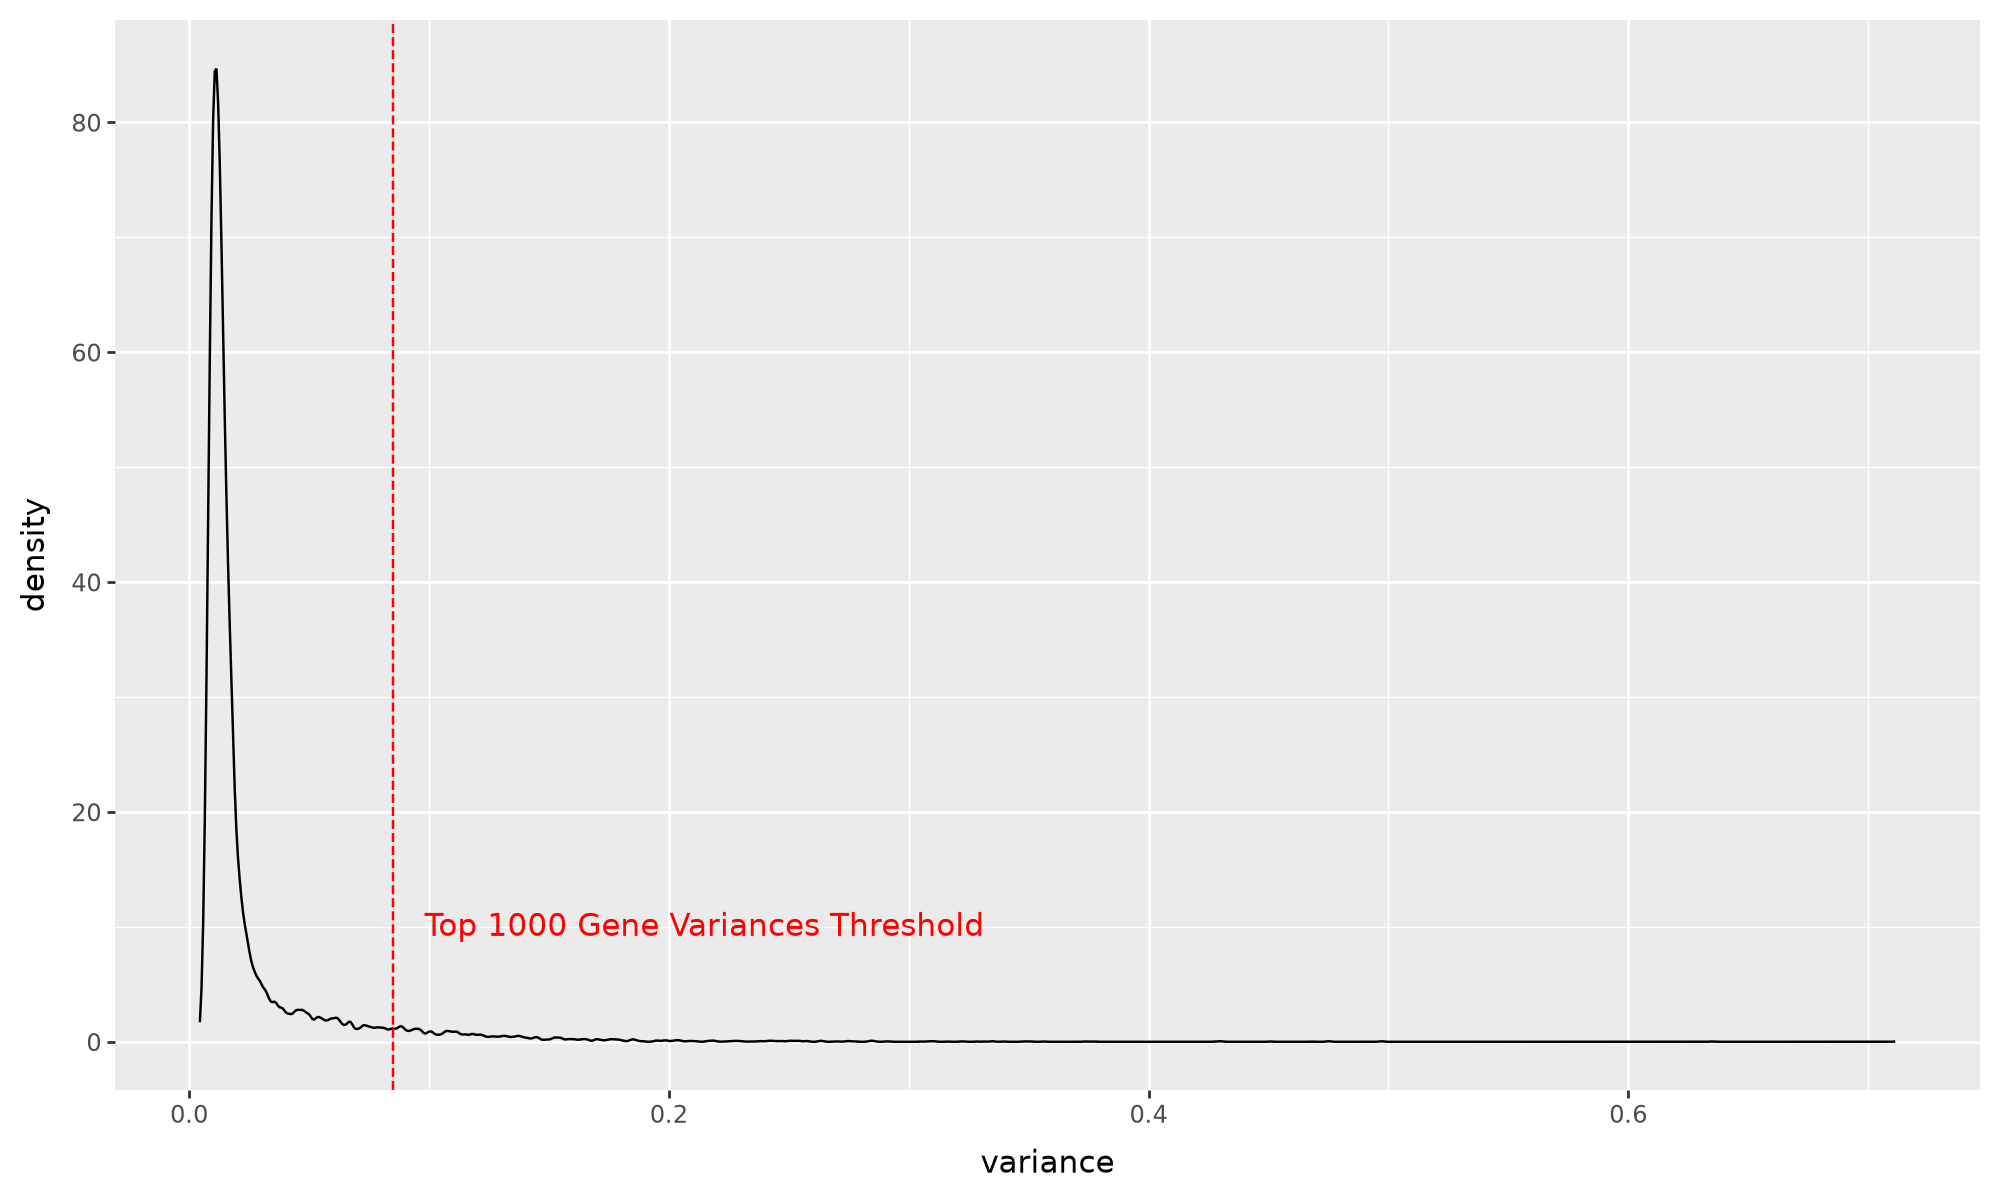

In [15]:
# finding the smallest gene variation out of the 1000 largest gene variations to set the top 1000 gene variances threshold
n = variance_df["variance"].nlargest(1000)
variance_threshold = n.astype(float).min()

# plotting variance density chart and marking the 1000 largest gene variation cutoff
variance_density_plot = (
    p9.ggplot(variance_df, p9.aes(x="variance"))
    + p9.geom_density()
    + p9.geom_vline(xintercept=variance_threshold, linetype="dashed", color="red")
    + p9.annotate(geom="text", x=variance_threshold + 0.13, y = 10, label="Top 1000 Gene Variances Threshold", color="red") 
    + p9.theme(figure_size=(10, 6))
)

# save the figure
density_path = pathlib.Path("./figures/variance_density_plot.png")
variance_density_plot.save(density_path)
variance_density_plot

In [16]:
# first create new dataframe containing gene info as well as both adult-pediatric and male-female t-test results and variance results
df = variance_df.assign(
    ttest_A_vs_P=t_test.t_stat.astype(float),
    ttest_M_vs_F=t_test_sex.t_stat.astype(float),
)

# and save the new dataframe as a .parquet
testing_df_output = pathlib.Path(
    "data/genes_variances_and_t-tests_df.parquet"
)
df.to_parquet(testing_df_output, index=False)
print(df.shape)
df.head(3)

(17107, 4)


,gene_ID,variance,ttest_A_vs_P,ttest_M_vs_F
0,A1BG (1),0.010377,1.867918,-0.636459
1,A1CF (29974),0.012438,-0.984714,0.690565
2,A2M (2),0.008775,0.902875,1.550377


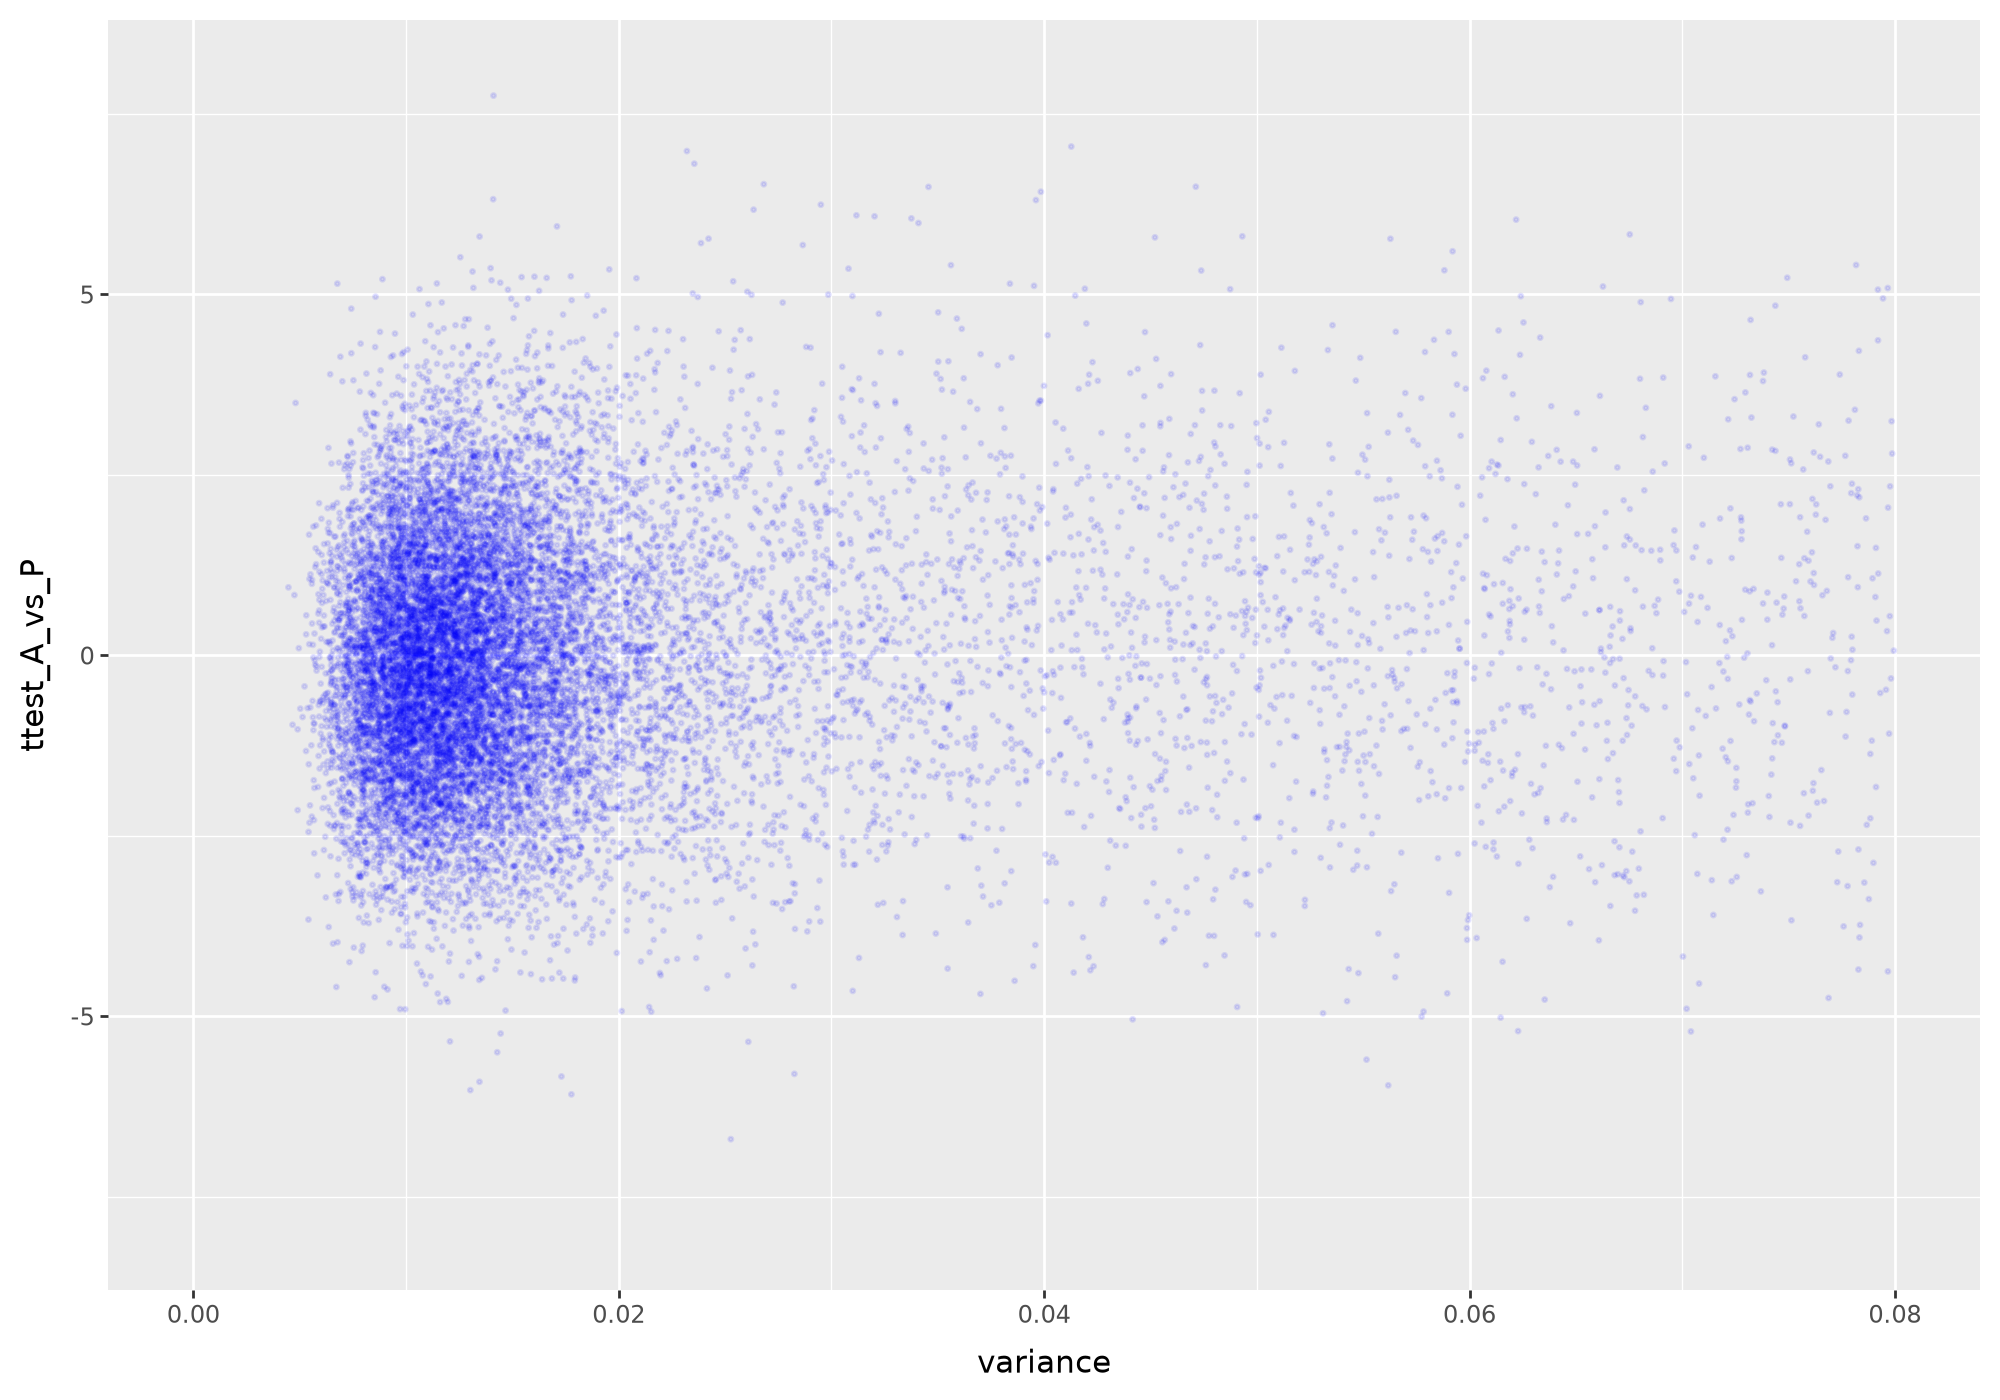

In [17]:
# plot adult-pediatric ttest versus variance
A_vs_P_by_variance_plot = (
    p9.ggplot(data=df, mapping=p9.aes(x="variance", y="ttest_A_vs_P"))
    + p9.geom_point(size=0.4, alpha=0.1, color="blue")
    + p9.theme(figure_size=(10, 7))
    + p9.xlim(0.00, 0.08)
    + p9.ylim(-8,8)
)

# save the figure
adult_vs_pediatric_path = pathlib.Path(
    "./figures/adult-pediatric_ttest_vs_variance.png"
)
A_vs_P_by_variance_plot.save(adult_vs_pediatric_path)
A_vs_P_by_variance_plot

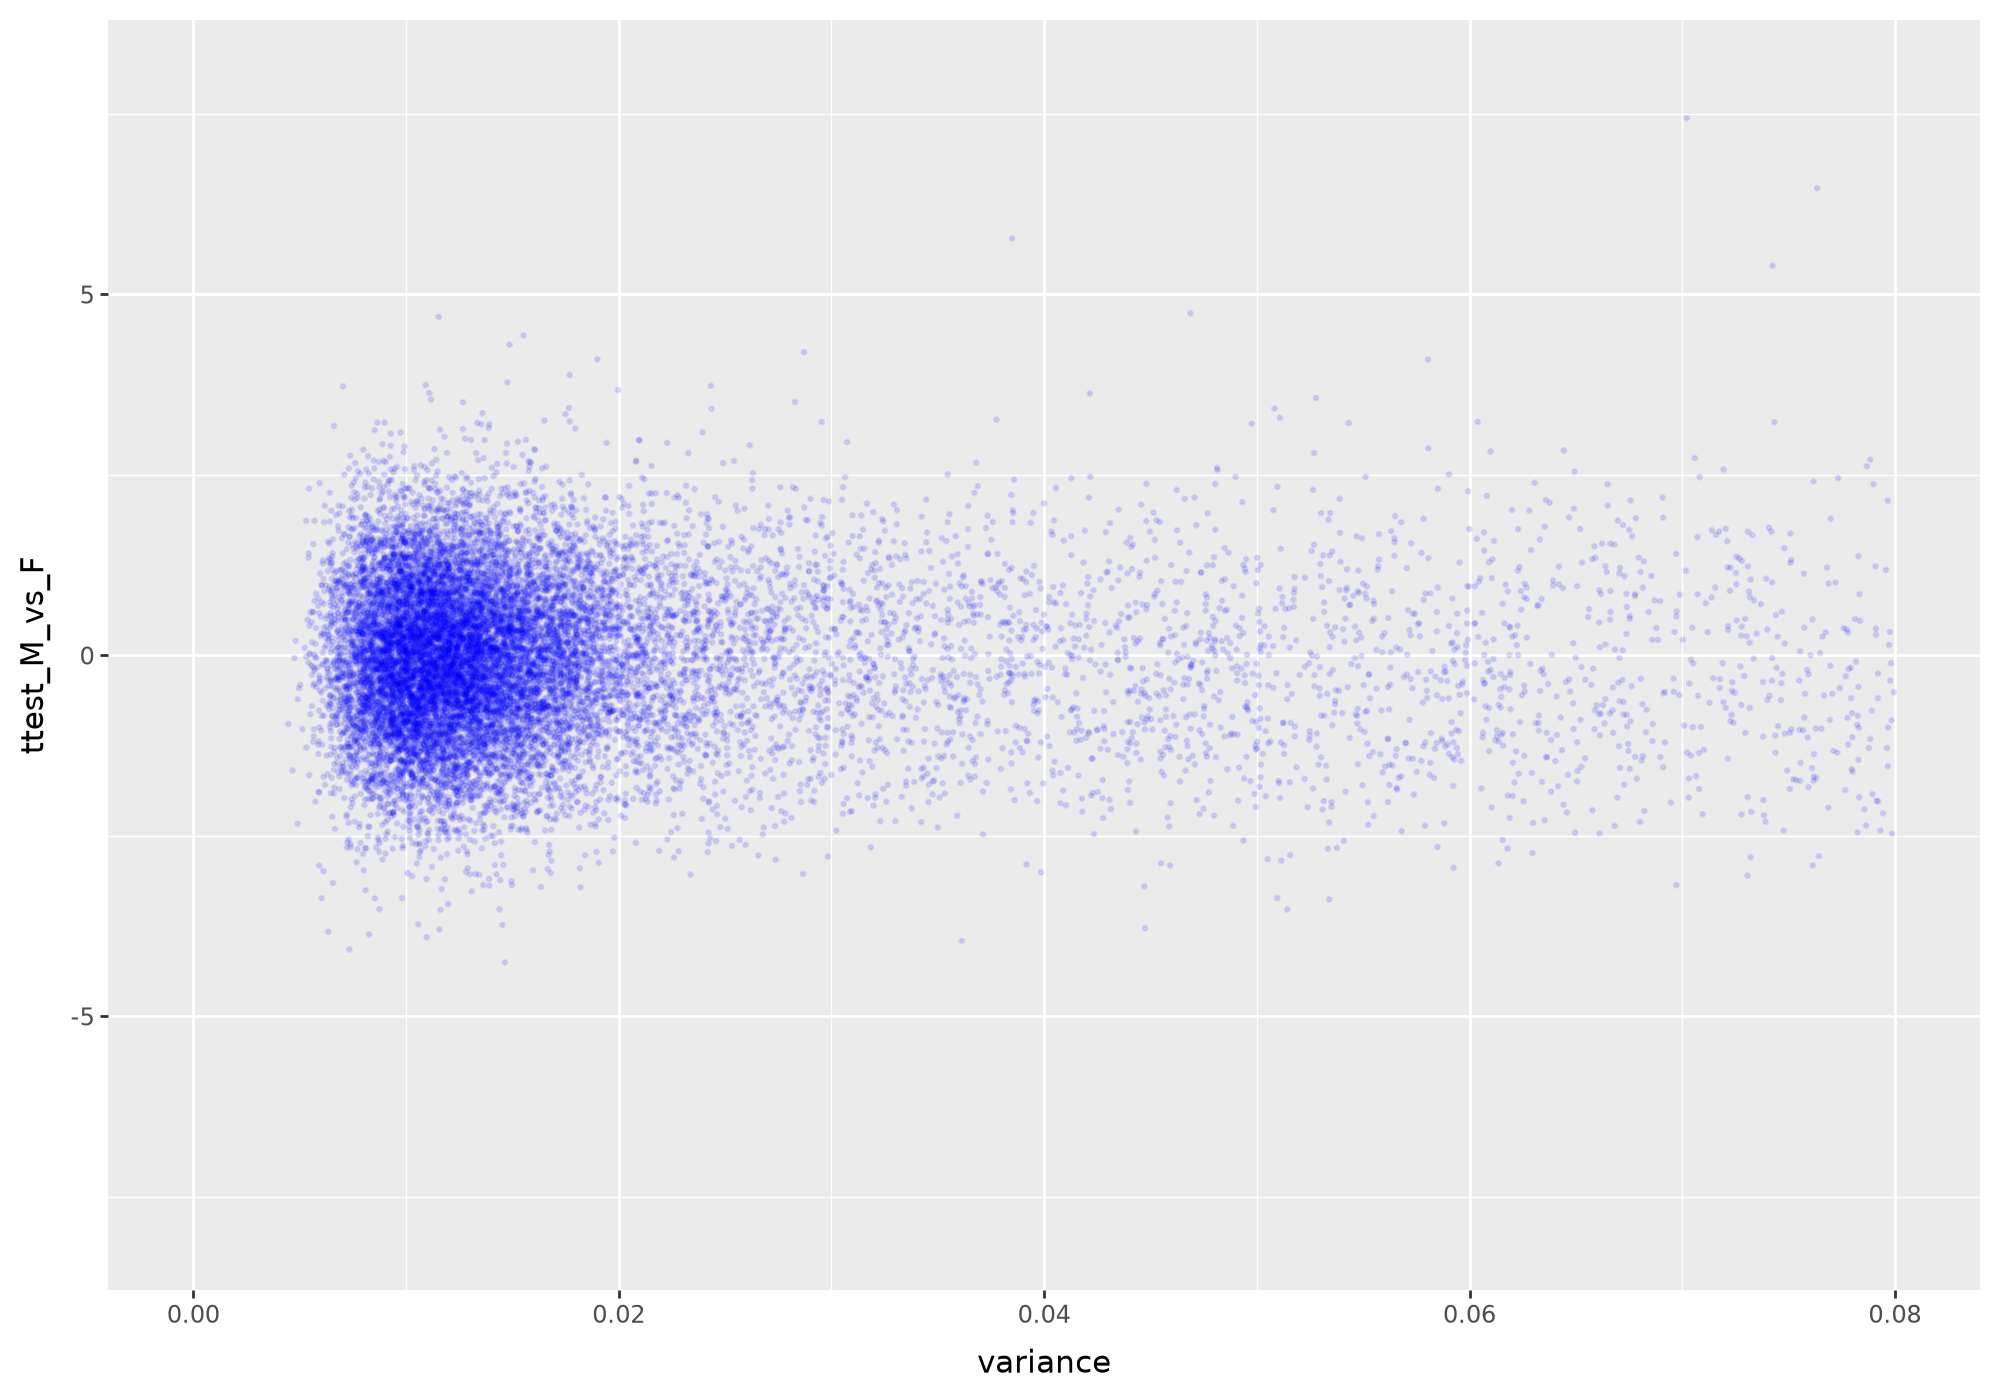

In [18]:
# plot male-female ttest versus gene variance
M_vs_F_by_variance_plot = (
    p9.ggplot(data=df, mapping=p9.aes(x="variance", y="ttest_M_vs_F"))
    + p9.geom_point(size=0.4, alpha=0.1, color="blue")
    + p9.theme(figure_size=(10, 7))
    + p9.xlim(0.00, 0.08)
    + p9.ylim(-8,8)
)

# save the figure
male_vs_female_path = pathlib.Path("./figures/male-female_ttest_vs_variance.png")
M_vs_F_by_variance_plot.save(male_vs_female_path)
M_vs_F_by_variance_plot